In [1]:
# imports
import torch

import numpy as np

import pandas as pd

In [2]:
from utils.data import download_all_papers

In [3]:
download_all_papers()

[INFO] File data/pdf/2001.08361.pdf already exists.
[INFO] File data/pdf/2203.15556.pdf already exists.
[INFO] File data/pdf/2005.03141.pdf already exists.
[INFO] File data/pdf/2306.10209.pdf already exists.
[INFO] File data/pdf/2307.08691.pdf already exists.
[INFO] File data/pdf/2312.00752.pdf already exists.
[INFO] File data/pdf/2309.06180.pdf already exists.
[INFO] File data/pdf/2406.03243.pdf already exists.
[INFO] File data/pdf/2211.17192.pdf already exists.
[INFO] File data/pdf/2401.10774.pdf already exists.
[INFO] File data/pdf/2211.10438.pdf already exists.
[INFO] File data/pdf/2306.00978.pdf already exists.
[INFO] File data/pdf/2306.14048.pdf already exists.
[INFO] File data/pdf/2310.01801.pdf already exists.
[INFO] File data/pdf/2101.03961.pdf already exists.
[INFO] File data/pdf/2106.06967.pdf already exists.
[INFO] File data/pdf/2408.03314.pdf already exists.
[INFO] File data/pdf/2408.00724.pdf already exists.
[INFO] File data/pdf/2303.11312.pdf already exists.
[INFO] File 

In [14]:
# Parser V1 (4 diffreent parsers)

import os, json, fitz

from utils1.text_parser import extract_text_sections
from utils1.figure_parser import extract_figures
from utils1.table_parser import extract_tables
from utils1.equation_parser import extract_equations
from utils1.utils import prepare_output_dir

# === Settings ===
pdf_path = "2001.08361.pdf"  # change to your PDF
doc_id = os.path.splitext(os.path.basename(pdf_path))[0]
doc = fitz.open(pdf_path)
output_dir = prepare_output_dir("parses", doc_id)

# === 1. Parse text ===
result = extract_text_sections(doc, doc_id)

# === 2. Parse figures ===
extract_figures(doc, doc_id, output_dir, result)

# === 3. Parse tables ===
extract_tables(doc, doc_id, output_dir, pdf_path, result)

# === 4. Parse equations ===
extract_equations(doc, doc_id, output_dir, result)

# === 5. Save final combined JSON ===
with open(os.path.join(output_dir, f"{doc_id}.json"), "w", encoding="utf-8") as f:
    json.dump(result, f, indent=2, ensure_ascii=False)

print(f"All done! Parsed content saved to: {output_dir}/{doc_id}.json")


/home/mt3846/envTorch124/lib/python3.10/site-packages/camelot/parsers/base.py:238: UserWarning: No tables found in table area (290.328, 203.8780828, 358.44735799999995, 346.90899260000003)
  cols, rows, v_s, h_s = self._generate_columns_and_rows(bbox, user_cols)


All done! Parsed content saved to: parses/2001.08361/2001.08361.json


In [ ]:
from docling.document_converter import DocumentConverter

converter = DocumentConverter()

result = converter.convert("https://arxiv.org/pdf/2408.09869")

document = result.document
markdown_output = document.export_to_markdown()
json_output = document.export_to_dict()

print(markdown_output)



In [61]:
from utils.docling_converter import batch_convert_pdfs

summary = batch_convert_pdfs("data/pdf", "data/docling_json1")

2025-10-28 02:11:58,469 - INFO - detected formats: [<InputFormat.PDF: 'pdf'>]
2025-10-28 02:11:58,479 - INFO - Going to convert document batch...
2025-10-28 02:11:58,480 - INFO - Initializing pipeline for StandardPdfPipeline with options hash 4f2edc0f7d9bb60b38ebfecf9a2609f5
2025-10-28 02:11:58,481 - INFO - Accelerator device: 'cuda:0'
[INFO] 2025-10-28 02:11:58,506 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2025-10-28 02:11:58,519 [RapidOCR] download_file.py:60: File exists and is valid: /home/mt3846/envTorch124/lib/python3.10/site-packages/rapidocr/models/ch_PP-OCRv4_det_infer.onnx
[INFO] 2025-10-28 02:11:58,520 [RapidOCR] main.py:53: Using /home/mt3846/envTorch124/lib/python3.10/site-packages/rapidocr/models/ch_PP-OCRv4_det_infer.onnx
[INFO] 2025-10-28 02:11:58,601 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2025-10-28 02:11:58,604 [RapidOCR] download_file.py:60: File exists and is valid: /home/mt3846/envTorch124/lib/python3.10/site-packages/rapido

Found 23 PDFs in /home/mt3846/ScaleRAG-Multimodal-Hierarchical/data/pdf


[INFO] 2025-10-28 02:11:58,671 [RapidOCR] download_file.py:60: File exists and is valid: /home/mt3846/envTorch124/lib/python3.10/site-packages/rapidocr/models/ch_PP-OCRv4_rec_infer.onnx
[INFO] 2025-10-28 02:11:58,672 [RapidOCR] main.py:53: Using /home/mt3846/envTorch124/lib/python3.10/site-packages/rapidocr/models/ch_PP-OCRv4_rec_infer.onnx
2025-10-28 02:11:58,766 - INFO - Auto OCR model selected rapidocr with onnxruntime.
2025-10-28 02:11:58,766 - INFO - Accelerator device: 'cuda:0'
2025-10-28 02:11:59,684 - INFO - Accelerator device: 'cuda:0'
2025-10-28 02:12:00,640 - INFO - Processing document 2001.08361.pdf
2025-10-28 02:12:20,688 - INFO - Finished converting document 2001.08361.pdf in 22.22 sec.
2025-10-28 02:12:20,778 - INFO - detected formats: [<InputFormat.PDF: 'pdf'>]
2025-10-28 02:12:20,781 - INFO - Going to convert document batch...
2025-10-28 02:12:20,782 - INFO - Processing document 2005.03141.pdf


 +++ Saved: 2001.08361.docling.json


2025-10-28 02:12:26,583 - INFO - Finished converting document 2005.03141.pdf in 5.81 sec.
2025-10-28 02:12:26,624 - INFO - detected formats: [<InputFormat.PDF: 'pdf'>]
2025-10-28 02:12:26,631 - INFO - Going to convert document batch...
2025-10-28 02:12:26,632 - INFO - Processing document 2101.03961.pdf


...

 +++ Saved: 2408.00724.docling.json


2025-10-28 02:18:43,512 - INFO - Finished converting document 2408.03314.pdf in 35.39 sec.
2025-10-28 02:18:43,593 - INFO - detected formats: [<InputFormat.PDF: 'pdf'>]


 +++ Saved: 2408.03314.docling.json


2025-10-28 02:18:43,787 - INFO - Going to convert document batch...
2025-10-28 02:18:43,788 - INFO - Processing document 2502.04524.pdf
2025-10-28 02:21:35,206 - INFO - Finished converting document 2502.04524.pdf in 171.62 sec.


 +++ Saved: 2502.04524.docling.json

Done. Success: 23, Failed: 0
JSONs saved in: /home/mt3846/ScaleRAG-Multimodal-Hierarchical/data/docling_json1


In [62]:
from utils.docling_to_rag import batch_convert_docling_to_rag

summary = batch_convert_docling_to_rag("data/docling_json", "data/rag_json1")
print(summary)

Found 23 Docling JSON files in 'data/docling_json'.


Converting Docling → RAG:  30%|███       | 7/23 [00:00<00:00, 62.49file/s]

Converted 2306.00978.docling.json → 2306.00978.rag.json (176 blocks)
Converted 2303.11312.docling.json → 2303.11312.rag.json (237 blocks)
Converted 2211.17192.docling.json → 2211.17192.rag.json (149 blocks)
Converted 2312.11514.docling.json → 2312.11514.rag.json (237 blocks)
Converted 2307.08691.docling.json → 2307.08691.rag.json (124 blocks)
Converted 2101.03961.docling.json → 2101.03961.rag.json (286 blocks)
Converted 2408.03314.docling.json → 2408.03314.rag.json (204 blocks)
Converted 2309.06180.docling.json → 2309.06180.rag.json (209 blocks)
Converted 2310.01801.docling.json → 2310.01801.rag.json (112 blocks)
Converted 2408.00724.docling.json → 2408.00724.rag.json (190 blocks)
Converted 2005.03141.docling.json → 2005.03141.rag.json (92 blocks)
Converted 2306.14048.docling.json → 2306.14048.rag.json (678 blocks)
Converted 2401.18059.docling.json → 2401.18059.rag.json (192 blocks)


Converting Docling → RAG:  87%|████████▋ | 20/23 [00:00<00:00, 55.34file/s]

Converted 2001.08361.docling.json → 2001.08361.rag.json (331 blocks)
Converted 2211.10438.docling.json → 2211.10438.rag.json (144 blocks)
Converted 2406.03243.docling.json → 2406.03243.rag.json (221 blocks)
Converted 2306.10209.docling.json → 2306.10209.rag.json (190 blocks)
Converted 2401.10774.docling.json → 2401.10774.rag.json (204 blocks)
Converted 2303.11313.docling.json → 2303.11313.rag.json (173 blocks)
Converted 2312.00752.docling.json → 2312.00752.rag.json (453 blocks)
Converted 2203.15556.docling.json → 2203.15556.rag.json (226 blocks)


Converting Docling → RAG: 100%|██████████| 23/23 [00:00<00:00, 54.96file/s]

Converted 2502.04524.docling.json → 2502.04524.rag.json (141 blocks)
Converted 2106.06967.docling.json → 2106.06967.rag.json (256 blocks)
{'total_files': 23, 'output_dir': 'data/rag_json1'}


In [63]:
from utils.pdf_image_extractor import enrich_rag_with_images

summary = enrich_rag_with_images()
print(summary)


Enriching RAG JSONs with images:   4%|▍         | 1/23 [00:01<00:35,  1.61s/it]

Enriched 2001.08361.rag.json


Enriching RAG JSONs with images:   9%|▊         | 2/23 [00:01<00:17,  1.19it/s]

Enriched 2005.03141.rag.json


Enriching RAG JSONs with images:  13%|█▎        | 3/23 [00:02<00:16,  1.23it/s]

...

Enriched 2408.00724.rag.json


Enriching RAG JSONs with images:  96%|█████████▌| 22/23 [00:23<00:01,  1.05s/it]

Enriched 2408.03314.rag.json


Enriching RAG JSONs with images: 100%|██████████| 23/23 [00:29<00:00,  1.29s/it]

Enriched 2502.04524.rag.json
Done. Updated 23 RAG JSON files with image paths.
{'updated_files': 23, 'rag_dir': 'data/rag_json1'}


# Chunking

In [67]:
from utils.chunk_merger import merge_short_text_chunks

merge_short_text_chunks()

✅ 2310.01801.rag.json: 112 chunks saved to 2310.01801.rag.chunks.json
✅ 2306.14048.rag.json: 661 chunks saved to 2306.14048.rag.chunks.json
✅ 2307.08691.rag.json: 118 chunks saved to 2307.08691.rag.chunks.json
✅ 2408.00724.rag.json: 190 chunks saved to 2408.00724.rag.chunks.json
✅ 2303.11313.rag.json: 173 chunks saved to 2303.11313.rag.chunks.json
✅ 2406.03243.rag.json: 221 chunks saved to 2406.03243.rag.chunks.json
✅ 2312.11514.rag.json: 234 chunks saved to 2312.11514.rag.chunks.json
✅ 2306.00978.rag.json: 173 chunks saved to 2306.00978.rag.chunks.json
✅ 2401.10774.rag.json: 203 chunks saved to 2401.10774.rag.chunks.json
✅ 2211.17192.rag.json: 145 chunks saved to 2211.17192.rag.chunks.json
✅ 2203.15556.rag.json: 223 chunks saved to 2203.15556.rag.chunks.json
✅ 2312.00752.rag.json: 436 chunks saved to 2312.00752.rag.chunks.json
✅ 2303.11312.rag.json: 229 chunks saved to 2303.11312.rag.chunks.json
✅ 2306.10209.rag.json: 182 chunks saved to 2306.10209.rag.chunks.json
✅ 2106.06967.rag.jso

5077

In [41]:
import json, glob
from pathlib import Path

chunk_dir = Path("data/rag_chunks")
stats = []

for file_path in sorted(chunk_dir.glob("*.json")):
    with open(file_path, "r", encoding="utf-8") as f:
        chunks = json.load(f)
    
    lengths = [len(ch.get("content", "").split()) for ch in chunks if "content" in ch]
    if not lengths:
        continue

    stats.append({
        "file": file_path.name,
        "num_chunks": len(chunks),
        "avg_words": sum(lengths) / len(lengths),
        "max_words": max(lengths),
        "min_words": min(lengths)
    })

# Display a summary table
from pprint import pprint
pprint(stats[:10])  # show first 10 papers

print(f"\nTotal processed papers: {len(stats)}")


[{'avg_words': 42.49843260188088,
  'file': '2001.08361.rag.chunks.json',
  'max_words': 181,
  'min_words': 1,
  'num_chunks': 319},
 {'avg_words': 51.2967032967033,
  'file': '2005.03141.rag.chunks.json',
  'max_words': 246,
  'min_words': 3,
  'num_chunks': 91},
 {'avg_words': 60.85281385281385,
  'file': '2101.03961.rag.chunks.json',
  'max_words': 560,
  'min_words': 2,
  'num_chunks': 231},
 {'avg_words': 40.921875,
  'file': '2106.06967.rag.chunks.json',
  'max_words': 242,
  'min_words': 1,
  'num_chunks': 256},
 {'avg_words': 55.16143497757847,
  'file': '2203.15556.rag.chunks.json',
  'max_words': 301,
  'min_words': 2,
  'num_chunks': 223},
 {'avg_words': 55.878571428571426,
  'file': '2211.10438.rag.chunks.json',
  'max_words': 256,
  'min_words': 1,
  'num_chunks': 140},
 {'avg_words': 56.144827586206894,
  'file': '2211.17192.rag.chunks.json',
  'max_words': 254,
  'min_words': 3,
  'num_chunks': 145},
 {'avg_words': 44.53711790393013,
  'file': '2303.11312.rag.chunks.jso

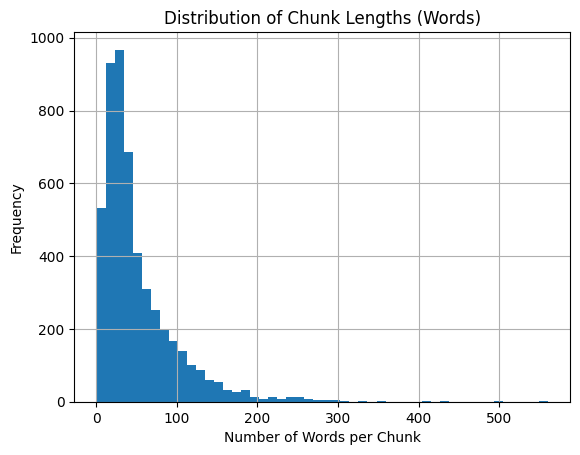

Average chunk length: 51 words
Total chunks across all files: 5077


In [42]:
import matplotlib.pyplot as plt

# Flatten all lengths across all documents
all_lengths = []
for file_path in chunk_dir.glob("*.json"):
    chunks = json.loads(file_path.read_text(encoding="utf-8"))
    all_lengths += [len(ch.get("content", "").split()) for ch in chunks if "content" in ch]

plt.hist(all_lengths, bins=50)
plt.title("Distribution of Chunk Lengths (Words)")
plt.xlabel("Number of Words per Chunk")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

print(f"Average chunk length: {sum(all_lengths)//len(all_lengths)} words")
print(f"Total chunks across all files: {len(all_lengths)}")


In [43]:
from transformers import GPT2TokenizerFast

tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")

def count_tokens(text):
    return len(tokenizer.encode(text))

token_stats = []
for file_path in chunk_dir.glob("*.json"):
    chunks = json.loads(file_path.read_text(encoding="utf-8"))
    lengths = [count_tokens(ch.get("content", "")) for ch in chunks if "content" in ch]
    if lengths:
        token_stats.append({
            "file": file_path.name,
            "avg_tokens": sum(lengths)/len(lengths),
            "max_tokens": max(lengths),
            "num_chunks": len(chunks)
        })

pprint(token_stats[:5])


Token indices sequence length is longer than the specified maximum sequence length for this model (1059 > 1024). Running this sequence through the model will result in indexing errors


[{'avg_tokens': 87.15384615384616,
  'file': '2406.03243.rag.chunks.json',
  'max_tokens': 364,
  'num_chunks': 221},
 {'avg_tokens': 72.42857142857143,
  'file': '2005.03141.rag.chunks.json',
  'max_tokens': 320,
  'num_chunks': 91},
 {'avg_tokens': 92.15606936416185,
  'file': '2306.00978.rag.chunks.json',
  'max_tokens': 360,
  'num_chunks': 173},
 {'avg_tokens': 89.15151515151516,
  'file': '2101.03961.rag.chunks.json',
  'max_tokens': 871,
  'num_chunks': 231},
 {'avg_tokens': 125.63235294117646,
  'file': '2408.03314.rag.chunks.json',
  'max_tokens': 1022,
  'num_chunks': 204}]


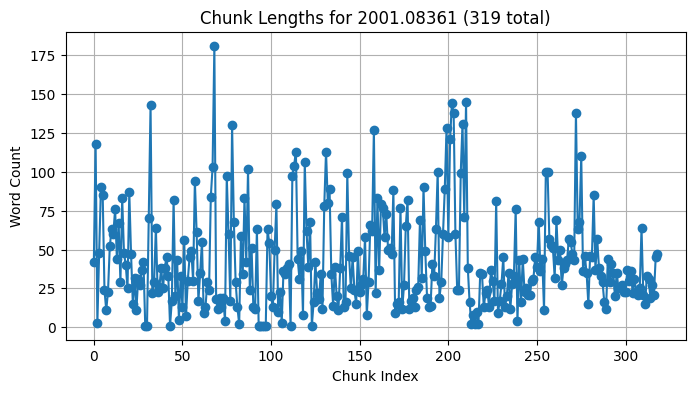

Average: 42 words | Max: 181


In [44]:
import json
import matplotlib.pyplot as plt
from pathlib import Path

paper_id = "2001.08361"
chunk_file = Path(f"data/rag_chunks/{paper_id}.rag.chunks.json")

if chunk_file.exists():
    chunks = json.loads(chunk_file.read_text())
    lengths = [len(ch["content"].split()) for ch in chunks if "content" in ch]
    plt.figure(figsize=(8,4))
    plt.plot(range(len(lengths)), lengths, marker='o')
    plt.title(f"Chunk Lengths for {paper_id} ({len(chunks)} total)")
    plt.xlabel("Chunk Index")
    plt.ylabel("Word Count")
    plt.grid(True)
    plt.show()

    print(f"Average: {sum(lengths)//len(lengths)} words | Max: {max(lengths)}")
else:
    print(f"❌ No chunk file found for {paper_id}")


In [45]:
import pandas as pd

df = pd.DataFrame(stats)
df_sorted = df.sort_values("avg_words", ascending=False)
display(df_sorted.head(10))


,file,num_chunks,avg_words,max_words,min_words
22,2502.04524.rag.chunks.json,140,87.900000,405,1
21,2408.03314.rag.chunks.json,204,73.029412,278,1
2,2101.03961.rag.chunks.json,231,60.852814,560,2
14,2310.01801.rag.chunks.json,112,59.821429,176,2
12,2307.08691.rag.chunks.json,118,58.279661,499,1
13,2309.06180.rag.chunks.json,204,58.191176,250,3
19,2406.03243.rag.chunks.json,221,58.135747,282,1
17,2401.10774.rag.chunks.json,203,56.655172,297,2
6,2211.17192.rag.chunks.json,145,56.144828,254,3
5,2211.10438.rag.chunks.json,140,55.878571,256,1


In [46]:
threshold = 800  # tokens
long_chunks = []

for file_path in chunk_dir.glob("*.json"):
    chunks = json.loads(file_path.read_text())
    for i, ch in enumerate(chunks):
        num_tokens = len(tokenizer.encode(ch.get("content", "")))
        if num_tokens > threshold:
            long_chunks.append({
                "file": file_path.name,
                "index": i,
                "tokens": num_tokens,
                "preview": ch.get("content", "")[:120]
            })

print(f"⚠️ Found {len(long_chunks)} chunks longer than {threshold} tokens")
for l in long_chunks[:5]:
    print(f"{l['file']}[{l['index']}]: {l['tokens']} tokens → {l['preview']}...")


⚠️ Found 4 chunks longer than 800 tokens
2101.03961.rag.chunks.json[169]: 871 tokens → import mesh tensorflow as mtf def switch layer(inputs, n, capacity factor, num experts): """Distributed switch transform...
2408.03314.rag.chunks.json[187]: 953 tokens → To convert $(θ，3)$ to polar coordinates，we need to find the radius $r$ and the angle $\theta$. Weknowthatthe$x$-coordina...
2408.03314.rag.chunks.json[192]: 1022 tokens → Sowehave$-6\leqa\leq-2$and$3\leqb\leq5$. And we want to find the greatest possible value of $\displaystyle\left(a+\frac{...
2307.08691.rag.chunks.json[46]: 1059 tokens → Require: Matrices Q , K , V ∈ R 𝑁 × 𝑑 in HBM, block sizes 𝐵 𝑐 , 𝐵 𝑟 . 1: Divide Q into 𝑇 𝑟 = l 𝑁 𝐵 𝑟 m blocks Q 1 , . . ...


# Embedding

In [40]:
import torch
from PIL import Image
# Text model (SentenceTransformer)
from sentence_transformers import SentenceTransformer
text_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

# Vision model (CLIP)
from transformers import CLIPProcessor, CLIPModel
clip_model_name = "openai/clip-vit-base-patch32"
clip_model = CLIPModel.from_pretrained(clip_model_name)
clip_processor = CLIPProcessor.from_pretrained(clip_model_name)

# Ensure models are on CPU or GPU as available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
clip_model = clip_model.to(device)
text_model = text_model


2025-10-27 23:59:28,934 - INFO - Use pytorch device_name: cuda:0
2025-10-27 23:59:28,935 - INFO - Load pretrained SentenceTransformer: sentence-transformers/all-MiniLM-L6-v2
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


# Embedding Chunks and Fusing Modalities

In [47]:
import numpy as np
from torch.nn.functional import normalize

embedded_chunks = []  # final list of chunk dicts with embeddings

text_chunks = [ch for ch in merged_chunks if ch['type'] in ['paragraph', 'text', 'equation']]
image_chunks = [ch for ch in merged_chunks if ch['type'] in ['figure', 'table']]

print(f"📄 Text chunks: {len(text_chunks)} | 🖼️ Image chunks: {len(image_chunks)}")

📄 Text chunks: 4707 | 🖼️ Image chunks: 370


In [48]:
# Batch compute text embeddings for all text chunks to speed up
texts = [ch['content'] for ch in text_chunks]
text_embeds = text_model.encode(texts, batch_size=32, show_progress_bar=True)
# text_embeds will be a numpy array of shape (len(text_chunks), 384) in this case

# Normalize text embeddings
text_embeds = text_embeds / np.linalg.norm(text_embeds, axis=1, keepdims=True)

# Assign back the text embeddings to their chunks
for ch, vec in zip(text_chunks, text_embeds):
    vec_list = vec.tolist()
    ch_emb = vec_list  # 384-dim text embedding
    # we handle that in the image loop instead.
    embedded_chunks.append({
        "id": ch["id"],
        "type": ch["type"],
        "content": ch["content"],
        "metadata": ch.get("metadata", {}).copy(),
        "embedding": ch_emb
    })

print(f"✅ Text embeddings computed for {len(text_chunks)} chunks.")

Batches:   0%|          | 0/148 [00:00<?, ?it/s]

✅ Text embeddings computed for 4707 chunks.


In [50]:
# Now handle image-containing chunks (figures, tables)
for ch in image_chunks:
    img_path = ch.get("metadata", {}).get("image_path") or ch.get("image_path")
    try:
        image = Image.open(img_path).convert("RGB")
    except Exception as e:
        print(f"Warning: could not open image at {img_path}: {e}")
        continue  # skip if image not available
    # Preprocess image for CLIP
    inputs = clip_processor(images=image, return_tensors="pt")
    pixel_values = inputs["pixel_values"].to(device)
    # Get CLIP image feature (512-dim)
    with torch.no_grad():
        image_feat = clip_model.get_image_features(pixel_values=pixel_values)
    image_vec = image_feat.cpu().numpy().flatten()
    # Normalize image embedding
    image_vec = image_vec / np.linalg.norm(image_vec)
    
    # Check if there's associated text (e.g., a caption in content)
    combined_vec = image_vec
    if ch.get("content"):
        caption = str(ch["content"])
        # Use the same text model for caption
        caption_emb = text_model.encode([caption])[0]
        caption_emb = caption_emb / np.linalg.norm(caption_emb)
        # Concatenate or average with image_vec:
        if caption_emb.shape[0] == image_vec.shape[0]:
            # If by chance using CLIP text encoder for caption, shapes align (512 each)
            combined_vec = (image_vec + caption_emb) / 2.0  # average
        else:
            # Different dimensions (e.g., 384 vs 512), concatenate
            combined_vec = np.concatenate([caption_emb, image_vec])
            # (combined_vec is now 896-dim in this scenario)
            # We could optionally reduce dimension or keep as is for indexing.
    else:
        # No caption text, combined_vec stays as image_vec
        pass

    embedded_chunks.append({
        "id": ch["id"],
        "type": ch["type"],
        "content": ch.get("content", ""),  # might be caption or empty
        "metadata": ch.get("metadata", {}).copy(),
        "embedding": combined_vec.tolist()
    })

print(f"Computed embeddings for {len(embedded_chunks)} chunks.")
# Show an example of a text chunk and an image chunk embedding (truncated for display)
for ex in embedded_chunks[:2]:
    print(f"{ex['type']} chunk '{ex['id']}' -> embedding length {len(ex['embedding'])}, sample: {ex['embedding'][:5]}")

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Computed embeddings for 5077 chunks.
paragraph chunk '2310.01801_paragraph_1' -> embedding length 384, sample: [0.007424895651638508, -0.04057932645082474, -0.012614581733942032, 0.05151136592030525, 0.06920088082551956]
paragraph chunk '2310.01801_paragraph_2' -> embedding length 384, sample: [-0.09076008200645447, -0.05950922891497612, -0.011276308447122574, 0.035979703068733215, -0.05466076731681824]


In [51]:
print(f"Computed embeddings for {len(embedded_chunks)} chunks.")
# Show an example of a text chunk and an image chunk embedding (truncated for display)
for ex in embedded_chunks[:2]:
    print(f"{ex['type']} chunk '{ex['id']}' -> embedding length {len(ex['embedding'])}, sample: {ex['embedding'][:5]}")

Computed embeddings for 5077 chunks.
paragraph chunk '2310.01801_paragraph_1' -> embedding length 384, sample: [0.007424895651638508, -0.04057932645082474, -0.012614581733942032, 0.05151136592030525, 0.06920088082551956]
paragraph chunk '2310.01801_paragraph_2' -> embedding length 384, sample: [-0.09076008200645447, -0.05950922891497612, -0.011276308447122574, 0.035979703068733215, -0.05466076731681824]


In [52]:
import random
sample = random.choice(embedded_chunks)
print(f"🧩 Sample chunk ({sample['type']}): {sample['content'][:150]}...")
print("Embedding length:", len(sample['embedding']))

🧩 Sample chunk (paragraph): Combining expert, model and data parallelism, we design two large Switch Transformer models, one with 395 billion and 1.6 trillion parameters, respect...
Embedding length: 384


In [53]:
import numpy as np

# How many chunks total?
num_chunks = len(embedded_chunks)
print(f"✅ Total embedded chunks: {num_chunks}")

# Check a few example types and embedding lengths
for ch in embedded_chunks[:5]:
    print(f"{ch['type']:>10} | embedding dim = {len(ch['embedding'])}")


✅ Total embedded chunks: 5077
 paragraph | embedding dim = 384
 paragraph | embedding dim = 384
 paragraph | embedding dim = 384
 paragraph | embedding dim = 384
 paragraph | embedding dim = 384


In [54]:
dims = [len(ch["embedding"]) for ch in embedded_chunks]
print(f"Average dimension: {np.mean(dims):.1f}")
print(f"Min dimension: {min(dims)}, Max dimension: {max(dims)}")

# How many unique embedding sizes (e.g., 384 for text, 512/896 for images)
unique_dims = sorted(set(dims))
print(f"Unique dimensions present: {unique_dims}")


Average dimension: 421.3
Min dimension: 384, Max dimension: 896
Unique dimensions present: [384, 896]


In [55]:
from collections import Counter
type_counts = Counter(ch["type"] for ch in embedded_chunks)
for t, c in type_counts.items():
    print(f"{t:>10}: {c} chunks")


 paragraph: 4328 chunks
  equation: 379 chunks
    figure: 249 chunks
     table: 121 chunks


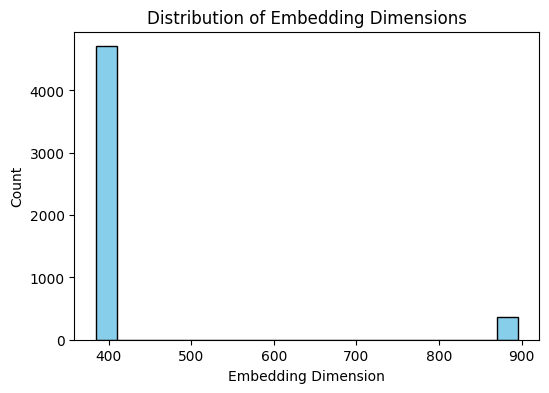

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(dims, bins=20, color='skyblue', edgecolor='black')
plt.title("Distribution of Embedding Dimensions")
plt.xlabel("Embedding Dimension")
plt.ylabel("Count")
plt.show()


In [58]:
import random
sample = random.choice(embedded_chunks)
print(f"🧩 Type: {sample['type']}")
print(f"📜 Content: {sample['content'][:200]}...")
print(f"🔢 Embedding length: {len(sample['embedding'])}")
print(f"📈 First 10 values: {sample['embedding'][:10]}")


🧩 Type: paragraph
📜 Content: We account for possible local minima by selecting the best fit from a grid of initialisations. The Huber loss ( 𝛿 = 10  3 ) is robust to outliers, which we find important for good predictive performan...
🔢 Embedding length: 384
📈 First 10 values: [-0.016936777159571648, -0.015504320152103901, 0.06622118502855301, 0.0772370919585228, 0.09625018388032913, -0.00015855794481467456, -0.026616398245096207, 0.025987986475229263, -0.053747255355119705, 0.02384178340435028]


In [59]:
text_dims = [len(ch["embedding"]) for ch in embedded_chunks if ch["type"] in ["text","paragraph","equation"]]
image_dims = [len(ch["embedding"]) for ch in embedded_chunks if ch["type"] in ["figure","table"]]

print(f"Text embeddings: mean {np.mean(text_dims):.0f} ± {np.std(text_dims):.1f}")
print(f"Image embeddings: mean {np.mean(image_dims):.0f} ± {np.std(image_dims):.1f}")


Text embeddings: mean 384 ± 0.0
Image embeddings: mean 896 ± 0.0


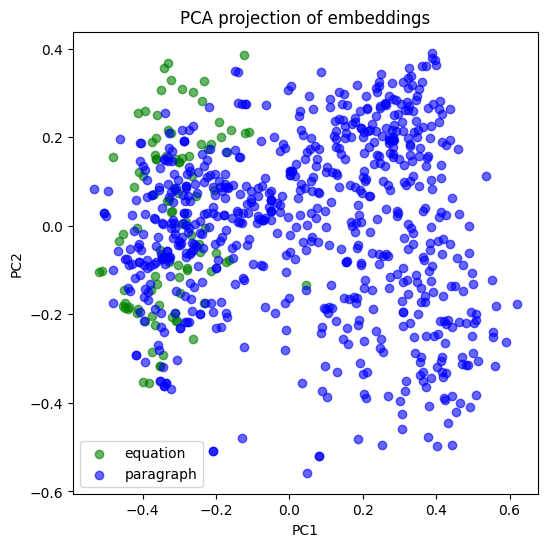

In [60]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Sample a manageable subset (for speed)
sampled = embedded_chunks[:800]
X = np.array([ch["embedding"] for ch in sampled])
labels = [ch["type"] for ch in sampled]

# Reduce to 2D
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

# Plot
plt.figure(figsize=(6,6))
colors = {"paragraph": "blue", "equation": "green", "figure": "red", "table": "orange"}
for t in set(labels):
    mask = [lbl == t for lbl in labels]
    plt.scatter(X_2d[mask,0], X_2d[mask,1], c=colors[t], label=t, alpha=0.6)
plt.legend()
plt.title("PCA projection of embeddings")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()


In [ ]:
import numpy as np
from torch.nn.functional import normalize

embedded_chunks = []  # final list of chunk dicts with embeddings

text_chunks = [ch for ch in merged_chunks if ch['type'] in ['paragraph', 'text', 'equation']]
image_chunks = [ch for ch in merged_chunks if ch['type'] in ['figure', 'table']]

# Batch compute text embeddings for all text chunks to speed up
texts = [ch['content'] for ch in text_chunks]
text_embeds = text_model.encode(texts, batch_size=32, show_progress_bar=True)
# text_embeds will be a numpy array of shape (len(text_chunks), 384) in this case

# Normalize text embeddings
text_embeds = text_embeds / np.linalg.norm(text_embeds, axis=1, keepdims=True)

# Assign back the text embeddings to their chunks
for ch, vec in zip(text_chunks, text_embeds):
    vec_list = vec.tolist()
    ch_emb = vec_list  # 384-dim text embedding
    # If this chunk also has an image (unlikely for type 'paragraph'; mostly figures have images)
    # we handle that in the image loop instead.
    embedded_chunks.append({
        "id": ch["id"],
        "type": ch["type"],
        "content": ch["content"],
        "metadata": ch.get("metadata", {}).copy(),
        "embedding": ch_emb
    })

# Now handle image-containing chunks (figures, tables)
for ch in image_chunks:
    img_path = ch.get("metadata", {}).get("image_path") or ch.get("image_path")
    try:
        image = Image.open(img_path).convert("RGB")
    except Exception as e:
        print(f"Warning: could not open image at {img_path}: {e}")
        continue  # skip if image not available
    # Preprocess image for CLIP
    inputs = clip_processor(images=image, return_tensors="pt")
    pixel_values = inputs["pixel_values"].to(device)
    # Get CLIP image feature (512-dim)
    with torch.no_grad():
        image_feat = clip_model.get_image_features(pixel_values=pixel_values)
    image_vec = image_feat.cpu().numpy().flatten()
    # Normalize image embedding
    image_vec = image_vec / np.linalg.norm(image_vec)
    
    # Check if there's associated text (e.g., a caption in content)
    combined_vec = image_vec
    if ch.get("content"):
        caption = str(ch["content"])
        # Use the same text model for caption (or we could use CLIP text encoder here for alignment)
        caption_emb = text_model.encode([caption])[0]
        caption_emb = caption_emb / np.linalg.norm(caption_emb)
        # Concatenate or average with image_vec:
        if caption_emb.shape[0] == image_vec.shape[0]:
            # If by chance using CLIP text encoder for caption, shapes align (512 each)
            combined_vec = (image_vec + caption_emb) / 2.0  # average
        else:
            # Different dimensions (e.g., 384 vs 512), concatenate
            combined_vec = np.concatenate([caption_emb, image_vec])
            # (combined_vec is now 896-dim in this scenario)
            # We could optionally reduce dimension or keep as is for indexing.
    else:
        # No caption text, combined_vec stays as image_vec
        pass

    embedded_chunks.append({
        "id": ch["id"],
        "type": ch["type"],
        "content": ch.get("content", ""),  # might be caption or empty
        "metadata": ch.get("metadata", {}).copy(),
        "embedding": combined_vec.tolist()
    })

print(f"Computed embeddings for {len(embedded_chunks)} chunks.")
# Show an example of a text chunk and an image chunk embedding (truncated for display)
for ex in embedded_chunks[:2]:
    print(f"{ex['type']} chunk '{ex['id']}' -> embedding length {len(ex['embedding'])}, sample: {ex['embedding'][:5]}")


# Storing Embeddings and Using a Vector Index

In [ ]:
output_path = "data/embedded_chunks/chunks.jsonl"
with open(output_path, 'w') as f:
    for ch in embedded_chunks:
        json.dump(ch, f)
        f.write('\n')
print(f"Saved {len(embedded_chunks)} embedded chunks to {output_path}")
